# Stage 3: ANFIS (Adaptive Neuro-Fuzzy Inference System) for AQI Prediction
==========================================================================
Uses PyTorch to implement an ANFIS model exploring:
- Gaussian membership function parameters (centers, sigmas)
- First-order Sugeno consequent weights

The manual Sugeno FIS from Stage 1 is included for comparison.

In [37]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from helper import fuzzify, evaluate_rule, sugeno_defuzzification, left_shoulder_mf, triangular_mf, right_shoulder_mf

## 1. Manual FIS Setup (for Comparison)
We include the Stage 1 configurations here to compare performances.

In [38]:
PM25_MF_CONFIG = {
    'Low':    ('left_shoulder', [30, 60]),
    'Medium': ('triangular', [45, 90, 135]),
    'High':   ('right_shoulder', [110, 200])
}

NO2_MF_CONFIG = {
    'Low':    ('left_shoulder', [40, 80]),
    'Medium': ('triangular', [60, 130, 200]),
    'High':   ('right_shoulder', [160, 300])
}

RULE_BASE = [
    {'if': [('pm2.5', 'High'),   ('no2', 'High')],   'then': 500},
    {'if': [('pm2.5', 'High'),   ('no2', 'Medium')], 'then': 350},
    {'if': [('pm2.5', 'High'),   ('no2', 'Low')],    'then': 250},
    {'if': [('pm2.5', 'Medium'), ('no2', 'High')],   'then': 350},
    {'if': [('pm2.5', 'Medium'), ('no2', 'Medium')], 'then': 150},
    {'if': [('pm2.5', 'Medium'), ('no2', 'Low')],    'then': 100},
    {'if': [('pm2.5', 'Low'),    ('no2', 'High')],   'then': 250},
    {'if': [('pm2.5', 'Low'),    ('no2', 'Medium')], 'then': 100},
    {'if': [('pm2.5', 'Low'),    ('no2', 'Low')],    'then': 50},
]

def predict_aqi_manual(pm25_val, no2_val):
    p_fuzzy = fuzzify(pm25_val, PM25_MF_CONFIG)
    n_fuzzy = fuzzify(no2_val, NO2_MF_CONFIG)
    memberships = {'pm2.5': p_fuzzy, 'no2': n_fuzzy}
    firing_strengths = []
    rule_outputs = []
    for rule in RULE_BASE:
        w, z = evaluate_rule(memberships, rule)
        firing_strengths.append(w)
        rule_outputs.append(z)
    return sugeno_defuzzification(firing_strengths, rule_outputs)

## 2. ANFIS Model Definition

In [39]:
class ANFISLayer(nn.Module):
    def __init__(self, n_inputs=2, n_terms=3):
        super(ANFISLayer, self).__init__()
        self.n_inputs = n_inputs
        self.n_terms  = n_terms
        self.n_rules  = n_terms ** n_inputs

        init_centers = torch.linspace(0.1, 0.9, n_terms).unsqueeze(0).repeat(n_inputs, 1)
        self.centers = nn.Parameter(init_centers)
        self.sigmas  = nn.Parameter(torch.ones(n_inputs, n_terms) * 0.3)
        self.consequents = nn.Parameter(torch.randn(self.n_rules, n_inputs + 1) * 0.1)

        import itertools
        self.rule_idx = list(itertools.product(range(n_terms), repeat=n_inputs))

    def forward(self, x):
        batch = x.size(0)

        # Layer 1: Fuzzification
        x_exp = x.unsqueeze(2)
        c_exp = self.centers.unsqueeze(0)
        s_exp = self.sigmas.unsqueeze(0).abs() + 1e-6
        mu = torch.exp(-((x_exp - c_exp) ** 2) / (2 * s_exp ** 2))

        # Layer 2: Rule Firing — FIX: pakai stack bukan inplace multiply
        w_list = []
        for r, idx in enumerate(self.rule_idx):
            w_r = mu[:, 0, idx[0]]
            for i in range(1, len(idx)):
                w_r = w_r * mu[:, i, idx[i]]  # bukan inplace, buat tensor baru
            w_list.append(w_r)
        w = torch.stack(w_list, dim=1)  # (batch, n_rules)

        # Layer 3: Normalisasi
        w_sum  = w.sum(dim=1, keepdim=True) + 1e-8
        w_norm = w / w_sum

        # Layer 4: Consequent
        x_aug = torch.cat([x, torch.ones(batch, 1, device=x.device)], dim=1)
        f = x_aug @ self.consequents.T

        # Layer 5: Output
        output = (w_norm * f).sum(dim=1, keepdim=True)
        return output

## 3. Data Preparation

In [40]:
def prepare_data(csv_path='dataset/city_day.csv', batch_size=64, test_size=0.2):
    # Reproducibility
    torch.manual_seed(42)
    np.random.seed(42)

    raw_df = pd.read_csv(csv_path)
    
    # Filter Delhi only
    aqi_df = raw_df[raw_df['City'] == 'Delhi'][['PM2.5', 'NO2', 'AQI']].dropna().copy()

    print(f'Data points for ANFIS training: {len(aqi_df)} (Delhi dataset)')

    X_vals = aqi_df[['PM2.5', 'NO2']].values
    y_vals = aqi_df[['AQI']].values

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_norm = scaler_X.fit_transform(X_vals)
    y_norm = scaler_y.fit_transform(y_vals)

    X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=test_size, random_state=42)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

    train_ds = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    return {
        'train_loader': train_loader, 'X_train_t': X_train_t, 'y_train_t': y_train_t,
        'X_test_t': X_test_t, 'y_test_t': y_test_t, 'X_test': X_test, 'y_test': y_test,
        'scaler_X': scaler_X, 'scaler_y': scaler_y, 'device': device
    }

## 4. Training Loop

In [41]:
def train_anfis(model, data, n_epochs=150, patience=20, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_state_dict = None
    no_improve = 0

    print('Starting training...')
    print(f'{"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>12} | {"LR":>10}')
    print('-' * 50)

    for epoch in range(1, n_epochs + 1):
        model.train()
        batch_losses = []
        for xb, yb in data['train_loader']:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(data['X_test_t']), data['y_test_t']).item()
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        
        if epoch % 25 == 0 or epoch == 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'{epoch:>6} | {train_loss:>12.6f} | {val_loss:>12.6f} | {lr_now:>10.6f}')
        
        if no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch}')
            break
    
    model.load_state_dict(best_state_dict)
    print(f'\nSelesai. Best val loss: {best_val_loss:.6f}')
    return train_losses, val_losses

## 5. Evaluation and Visualization

In [42]:
def evaluate_and_compare(model, data):
    scaler_y = data['scaler_y']
    scaler_X = data['scaler_X']
    model.eval()
    with torch.no_grad():
        y_pred_norm = model(data['X_test_t']).cpu().numpy()
    
    y_pred_ann = scaler_y.inverse_transform(y_pred_norm).flatten()
    y_true = scaler_y.inverse_transform(data['y_test']).flatten()
    X_test_raw = scaler_X.inverse_transform(data['X_test'])
    y_pred_manual = np.array([predict_aqi_manual(row[0], row[1]) for row in X_test_raw])
    
    print(f'Manual FIS MAE: {mean_absolute_error(y_true, y_pred_manual):.2f}')
    from sklearn.metrics import mean_squared_error
    print(f'ANFIS MAE: {mean_absolute_error(y_true, y_pred_ann):.2f}')
    print(f'ANFIS RMSE: {np.sqrt(mean_squared_error(y_true, y_pred_ann)):.2f}')
    print(f'ANFIS R2: {r2_score(y_true, y_pred_ann):.4f}')
    
    return {
        'y_true': y_true, 
        'y_pred_ann': y_pred_ann, 
        'y_pred_manual': y_pred_manual
    }

# Run
data = prepare_data()
model = ANFISLayer(n_inputs=2, n_terms=3).to(data['device'])
# Capture initial parameters for visualization
initial_centers = model.centers.detach().cpu().clone().numpy()
initial_sigmas = model.sigmas.detach().cpu().clone().numpy()
train_losses, val_losses = train_anfis(model, data)
metrics = evaluate_and_compare(model, data)
y_true, y_pred_ann, y_pred_manual = metrics['y_true'], metrics['y_pred_ann'], metrics['y_pred_manual']

Data points for ANFIS training: 1998 (Delhi dataset)
Using device: cpu
Starting training...
 Epoch |   Train Loss |     Val Loss |         LR
--------------------------------------------------
     1 |     0.059758 |     0.017267 |   0.010000
    25 |     0.005849 |     0.004666 |   0.010000
    50 |     0.005717 |     0.004592 |   0.010000
    75 |     0.005583 |     0.004570 |   0.010000

Early stopping at epoch 98

Selesai. Best val loss: 0.004531
Manual FIS MAE: 105.18
ANFIS MAE: 34.03
ANFIS RMSE: 46.25
ANFIS R2: 0.8553


## 6. Training Progress and MF Tuning

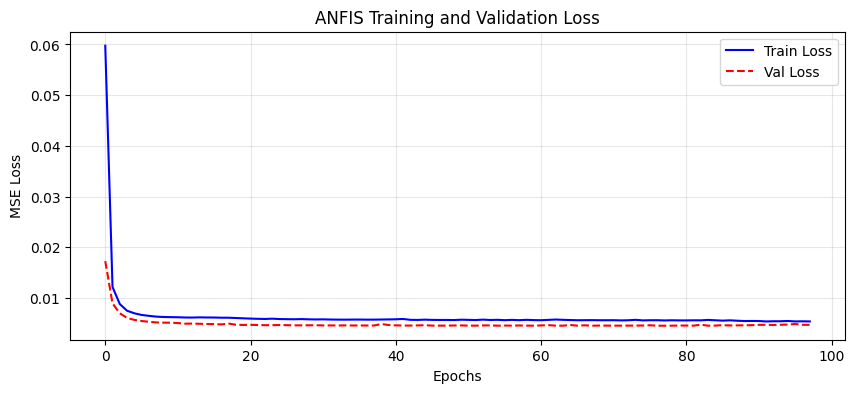

In [43]:
# Plot Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='red', linestyle='--')
plt.title('ANFIS Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

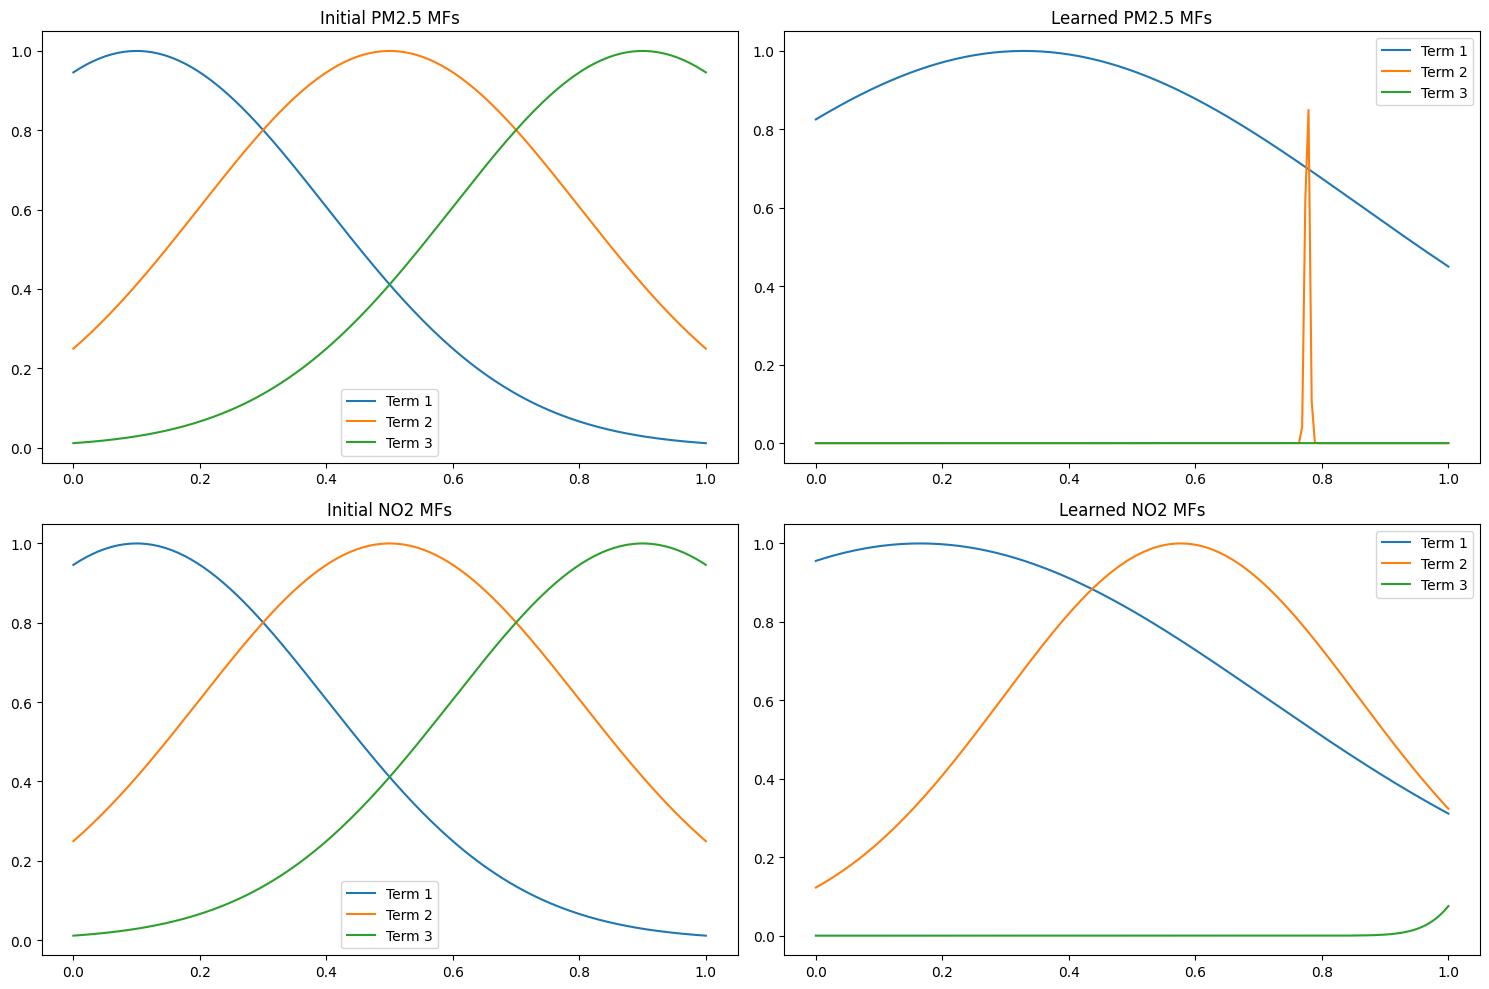

In [44]:
def plot_all_mfs(model, init_c, init_s):
    learned_c = model.centers.detach().cpu().numpy()
    learned_s = model.sigmas.detach().cpu().numpy()
    
    x = np.linspace(0, 1, 200)
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    input_names = ['PM2.5', 'NO2']
    
    for i in range(2):
        # Initial MFs
        for j in range(model.n_terms):
            c, s = init_c[i, j], np.abs(init_s[i, j]) + 1e-6
            y = np.exp(-((x - c)**2) / (2 * s**2))
            axes[i, 0].plot(x, y, label=f'Term {j+1}')
        axes[i, 0].set_title(f'Initial {input_names[i]} MFs')
        axes[i, 0].legend()
        
        # Learned MFs
        for j in range(model.n_terms):
            c, s = learned_c[i, j], np.abs(learned_s[i, j]) + 1e-6
            y = np.exp(-((x - c)**2) / (2 * s**2))
            axes[i, 1].plot(x, y, label=f'Term {j+1}')
        axes[i, 1].set_title(f'Learned {input_names[i]} MFs')
        axes[i, 1].legend()

    plt.tight_layout()
    plt.show()

plot_all_mfs(model, initial_centers, initial_sigmas)

## 7. Performance Comparison

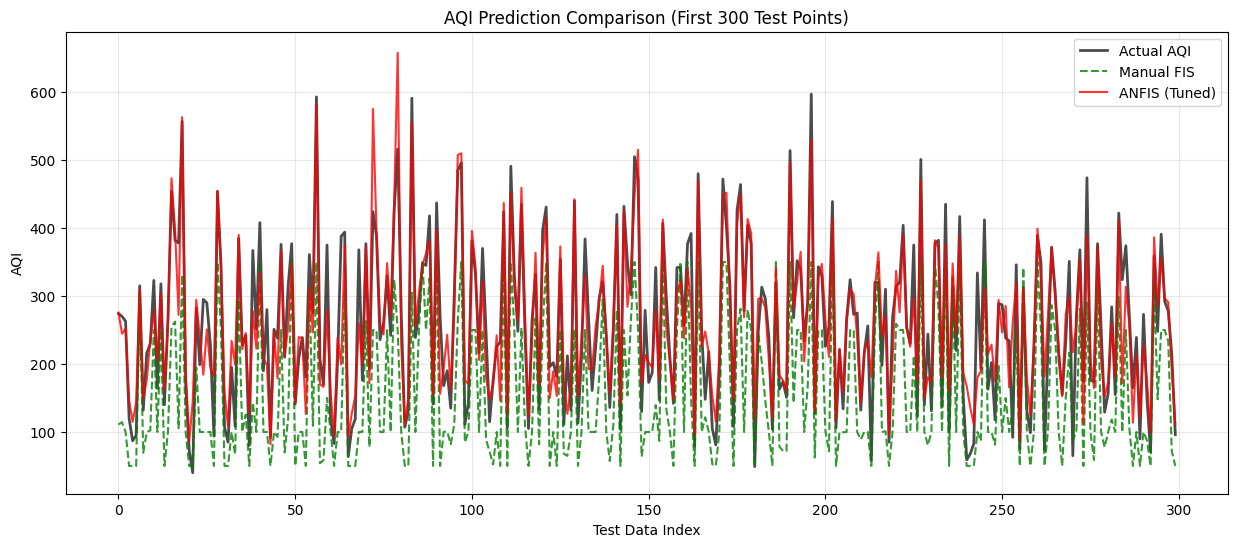

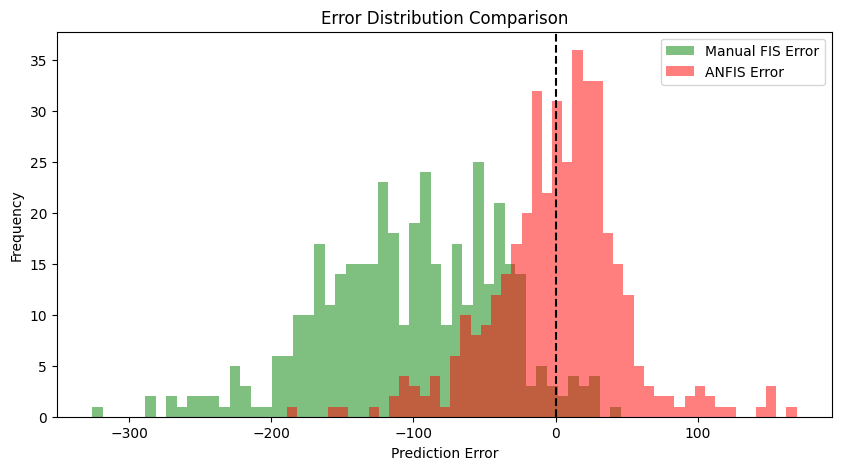

In [46]:
# Plot Actual vs Predicted (Sample)
plt.figure(figsize=(15, 6))
sample_size = 300
plt.plot(y_true[:sample_size], label='Actual AQI', color='black', alpha=0.7, linewidth=2)
plt.plot(y_pred_manual[:sample_size], label='Manual FIS', color='green', linestyle='--', alpha=0.8)
plt.plot(y_pred_ann[:sample_size], label='ANFIS (Tuned)', color='red', alpha=0.8)

plt.title(f'AQI Prediction Comparison (First {sample_size} Test Points)')
plt.xlabel('Test Data Index')
plt.ylabel('AQI')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Error Distribution
plt.figure(figsize=(10, 5))
error_manual = y_pred_manual - y_true
error_anfis = y_pred_ann - y_true
plt.hist(error_manual, bins=50, alpha=0.5, label='Manual FIS Error', color='green')
plt.hist(error_anfis, bins=50, alpha=0.5, label='ANFIS Error', color='red')
plt.axvline(0, color='black', linestyle='--')
plt.title('Error Distribution Comparison')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.legend()
plt.show()